<a href="https://colab.research.google.com/github/kaplunov-dmitrii/diffury/blob/main/2253_%D0%9A%D0%B0%D0%BF%D0%BB%D1%83%D0%BD%D0%BE%D0%B2_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D1%80%D1%83%D1%87%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание 1

Капля воды падает в воздухе и испытывает сопротивление воздуха, пропорциональное её скорости. Решить обыкновенное дифференциальное уравнение (ОДУ) аналитически (символьно) с помощью SymPy и построить график скорости относительно времени.

Модель капли в виде ОДУ была составлена на доске:
$$\frac{dv}{dt} = g - \frac{k}{m}v$$

Сейчас мы проделаем похожую работу, но вместо ручного аналитического решения попробуем смоделировать задачу на компьютере, а затем воспроизвести и аналитическое решение с помощью символьных вычислений в библиотеке **SymPy**.

### Задача 1

Опишите комментариями каждую строку кода и каждый параметр в вызванных библиотечных функциях.

**Подключение библиотек**

In [ ]:
import sympy as sp #подключение библиотеки sympy, которая нужна для решения уравнений в буквенном виде
import numpy as np #numpy поможет создать набор чисел для времени, чтобы построить график
import matplotlib.pyplot as plt #matplotlib отвечает за рисование самого графика

**Определение констант**

In [ ]:
k = 0.1 #задаем коэффицент сопротивления воздуха
m = 1 #масса падающей капли
g = 9.81 #ускорение свободного падения

**Определение модели**

In [ ]:
t = sp.symbols('t') #создаем символьную переменную t (время), чтобы Python воспринимал ее как букву в формуле
v = sp.Function('v') #создаем символьную функцию v (скорость), которая будет зависеть от времени t

ode = sp.Eq(v(t).diff(t), g - k/m*v(t)) #записываем само ДУ. v(t).diff(t) - это производная dv/dt, а sp.Eq связывает 2 аргумента знаком равенства
ode #вместо print(ode)

Eq(Derivative(v(t), t), 9.81 - 0.1*v(t))

**Начальное условие и временная сетка**

In [ ]:
t0 = 0 #начальный момент времени
v0 = 0 #начальная скорость капли
t_end = 50 #конечный момент времени

t_space = np.linspace(t0, t_end, 500) #создаем массив из 500 точек от 0 до 50, чтобы получить плавный график

**Решение задачи и график**

In [ ]:
solution = sp.dsolve(ode, v(t), ics={v(t0): v0}) #dsolve решает уравнение ode с учетом начального условия
solution #вывод итоговой формулы на экран

Eq(v(t), 98.1 - 98.1*exp(-0.1*t))

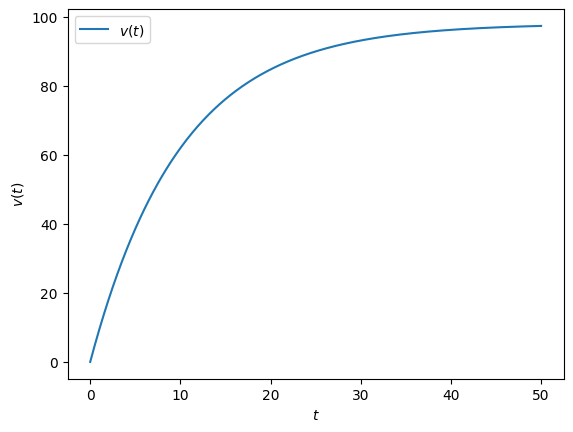

In [ ]:
v_func = sp.lambdify(t, solution.rhs, 'numpy') #превращает буквенное решение sympy в обычную функцию Python, которая может быстро посчитать массив чисел
v_values = v_func(t_space) #считает конкретные значения скорости для каждой из 500 точек времени

plt.plot(t_space, v_values, label=r'$v(t)$') #рисует график (Ox - время, Oy - скорость)
plt.xlabel(r'$t$') #подписывает ось x на графике
plt.ylabel(r'$v(t)$') #подписывает ось y на графике
plt.legend() #включает легенду (рамочки с описанием линий)
plt.show() #выводит график на экран

### Задача 2

Возьмите решение ОДУ, полученное аналитически у доски (вручную), запрограммируйте его и постройте график с двумя кривыми: символьным решением, полученным через SymPy (`solution`), и вашим "ручным" аналитическим решением. Кривую нужно определить по значениям функции $v(t)$ в заданных ранее точках по времени (`t_space`).

NB: обе кривые — это аналитические (точные) решения одного и того же ОДУ, полученные двумя разными способами: одно — компьютером через `dsolve`, другое — руками на бумаге. Цель задания — убедиться, что они совпадают.

In [ ]:
# Решение на основе полученной вручную (у доски) функции скорости от времени
v_analytical = 98.1 - 98.1 * np.exp(-0.1 * t_space)


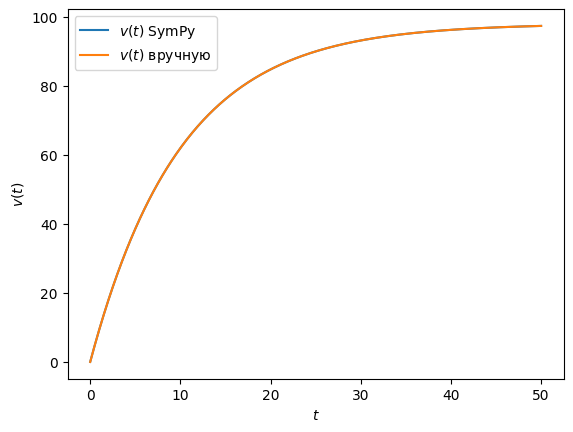

In [ ]:
plt.plot(t_space, v_values, label=r'$v(t)$ SymPy')
plt.plot(t_space, v_analytical, label=r'$v(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$v(t)$')
plt.legend()
plt.show()


## Задание 2

Горячий металлический шарик вынимают из печи, где он нагрелся до температуры $T_0$, и оставляют остывать в помещении с постоянной температурой воздуха $T_{env}$. Согласно закону теплообмена Ньютона, скорость изменения температуры тела пропорциональна разности между температурой тела и температурой окружающей среды.

### Вывод дифференциального уравнения

1. Пусть $T(t)$ — температура тела в момент времени $t$.
2. Закон Ньютона об охлаждении гласит, что скорость изменения температуры тела пропорциональна разности $T(t) - T_{env}$:
$$\frac{dT}{dt} \propto -\big(T(t) - T_{env}\big)$$
Знак минус — потому что тело остывает, если оно горячее среды ($T > T_{env}$, значит $dT/dt < 0$), и нагревается, если холоднее ($T < T_{env}$, значит $dT/dt > 0$).
3. Введём коэффициент теплоотдачи $h > 0$ (зависит от материала, площади поверхности шарика и условий конвекции воздуха):
$$\frac{dT}{dt} = -h\,\big(T(t) - T_{env}\big)$$
4. Получили линейное ОДУ первого порядка с постоянными коэффициентами — по структуре оно полностью аналогично уравнению для скорости капли из Задания 1 (там производная тоже линейно зависела от самой функции).

### Задача

По аналогии с Заданием 1:
1. Решите поставленное ОДУ аналитически на бумаге.
2. Задайте константы $h$, $T_{env}$, начальное условие $T(0) = T_0$ и временную сетку.
3. Получите аналитическое решение с помощью SymPy (`dsolve`) с учётом начального условия.
4. Постройте график кривой решения с помощью SymPy и "ручного" решения и убедитесь, что они совпадают.

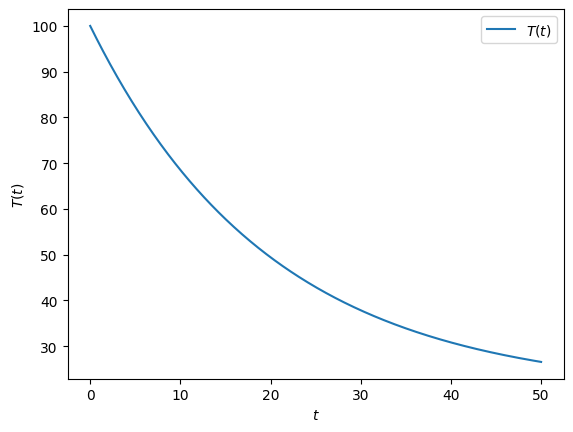

In [ ]:
# Решите Задание 2 в этой ячейке (или добавьте столько ячеек, сколько нужно):
# 1) константы, начальное условие, временная сетка
# 2) ОДУ через sp.Eq(...)
# 3) sp.dsolve(...) с ics
# 4) график: решение SymPy + ваше решение вручную
t = sp.symbols('t') #создаем символьную переменную t (время), чтобы Python воспринимал ее как букву в формуле
T = sp.Function('T') #создаем символьную функцию, которая будет зависеть от времени t
T_env = 20
h = 0.05
T0 = 100
t0 = 0
t_end = 50
ode = sp.Eq(T(t).diff(t), -h*(T(t) - T_env)) #записываем само ДУ. sp.Eq связывает 2 аргумента знаком равенства

t_space = np.linspace(t0, t_end, 500) #создаем массив из 500 точек от 0 до 50, чтобы получить плавный график

solution = sp.dsolve(ode, T(t), ics={T(t0): T0}) #dsolve решает уравнение ode с учетом начального условия
T_func = sp.lambdify(t, solution.rhs, 'numpy') #превращает буквенное решение sympy в обычную функцию Python, которая может быстро посчитать массив чисел
T_values = T_func(t_space) #считает конкретные значения скорости для каждой из 500 точек времени

plt.plot(t_space, T_values, label=r'$T(t)$') #рисует график (Ox - время, Oy - скорость)
plt.xlabel(r'$t$') #подписывает ось x на графике
plt.ylabel(r'$T(t)$') #подписывает ось y на графике
plt.legend() #включает легенду (рамочки с описанием линий)
plt.show() #выводит график на экран

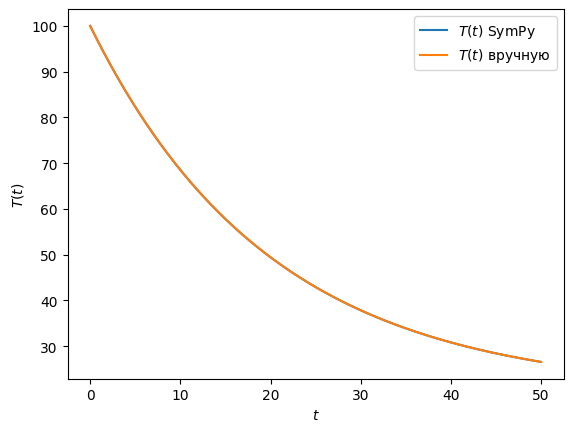

In [ ]:
T_analytical = np.exp(-h*t_space) * (T0 - T_env) + T_env

plt.plot(t_space, T_values, label=r'$T(t)$ SymPy')
plt.plot(t_space, T_analytical, label=r'$T(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$T(t)$')
plt.legend()
plt.show()

## Задание 3

Конденсатор ёмкостью $C$ заряжается через резистор сопротивлением $R$ от источника постоянного напряжения $V_s$ (классическая RC-цепь). Нужно определить, как напряжение на конденсаторе $V(t)$ изменяется со временем в процессе зарядки.

### Вывод дифференциального уравнения

1. Пусть $V(t)$ — напряжение на конденсаторе в момент времени $t$, а $Q(t) = C\,V(t)$ — накопленный на его обкладках заряд.
2. По второму закону Кирхгофа (закон напряжений) сумма падений напряжения в контуре равна ЭДС источника:
$$V_s = I(t)\,R + V(t)$$
где $I(t)$ — ток зарядки, текущий через резистор.
3. Ток равен скорости прихода заряда на обкладки конденсатора:
$$I(t) = \frac{dQ}{dt} = C\,\frac{dV}{dt}$$
4. Подставляя выражение для тока в закон Кирхгофа, получаем:
$$V_s = RC\,\frac{dV}{dt} + V(t) \quad\Longrightarrow\quad \frac{dV}{dt} = \frac{V_s - V(t)}{RC}$$
5. Получили линейное ОДУ первого порядка с постоянными коэффициентами — той же структуры, что и в Заданиях 1 и 2: скорость изменения $V$ пропорциональна разности между текущим значением $V$ и "равновесным" значением $V_s$, к которому стремится напряжение (роль коэффициента $h$ из Задания 2 здесь играет $1/(RC)$).

### Задача

По аналогии с Заданиями 1 и 2:
1. Решите поставленное ОДУ аналитически на бумаге.
2. Задайте константы $R$, $C$, $V_s$, начальное условие $V(0) = V_0$ (например, разряженный конденсатор, $V_0 = 0$) и временную сетку.
3. Получите аналитическое решение с помощью SymPy (`dsolve`) с учётом начального условия.
4. Постройте график кривой решения с помощью SymPy и "ручного" решения и убедитесь, что они совпадают.

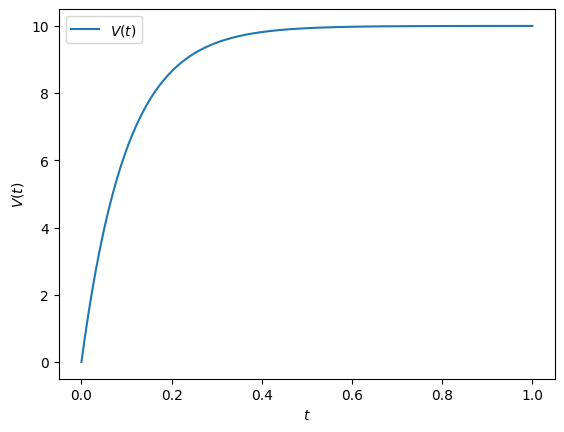

In [ ]:
# Решите Задание 3 в этой ячейке (или добавьте столько ячеек, сколько нужно):
# 1) константы, начальное условие, временная сетка
# 2) ОДУ через sp.Eq(...)
# 3) sp.dsolve(...) с ics
# 4) график: решение SymPy + ваше решение вручную
t = sp.symbols('t') #создаем символьную переменную t (время), чтобы Python воспринимал ее как букву в формуле
V = sp.Function('V') #создаем символьную функцию, которая будет зависеть от времени t
Vs = 10
R = 1000
C = 0.0001
t0 = 0
t_end = 1
V0 = 0
ode = sp.Eq(V(t).diff(t), (Vs - V(t)) / (R * C)) #записываем само ДУ. sp.Eq связывает 2 аргумента знаком равенства

t_space = np.linspace(t0, t_end, 500) #создаем массив из 500 точек от 0 до 50, чтобы получить плавный график

solution = sp.dsolve(ode, V(t), ics={V(t0): V0}) #dsolve решает уравнение ode с учетом начального условия
V_func = sp.lambdify(t, solution.rhs, 'numpy') #превращает буквенное решение sympy в обычную функцию Python, которая может быстро посчитать массив чисел
V_values = V_func(t_space) #считает конкретные значения скорости для каждой из 500 точек времени

plt.plot(t_space, V_values, label=r'$V(t)$') #рисует график (Ox - время, Oy - скорость)
plt.xlabel(r'$t$') #подписывает ось x на графике
plt.ylabel(r'$V(t)$') #подписывает ось y на графике
plt.legend() #включает легенду (рамочки с описанием линий)
plt.show() #выводит график на экран


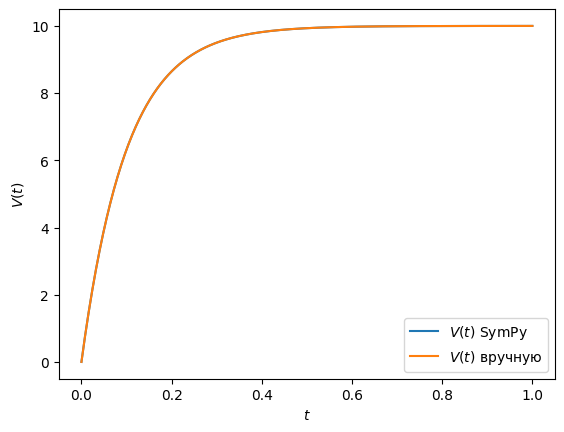

In [ ]:
V_analytical = Vs - (Vs - V0) * np.exp(-t_space / (R * C))

plt.plot(t_space, V_values, label=r'$V(t)$ SymPy')
plt.plot(t_space, V_analytical, label=r'$V(t)$ вручную')
plt.xlabel(r'$t$')
plt.ylabel(r'$V(t)$')
plt.legend()
plt.show()